# Exploratory Data Analysis — Pima Indians Diabetes Dataset

This notebook explores the dataset to understand feature distributions, class balance, correlations, and potential data-quality issues before building a neural network.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
%matplotlib inline

## 1. Load the Dataset

In [2]:
df = pd.read_csv('../dataset/diabetes.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 2. Dataset Info & Data Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Check for explicit null values
print('Null values per column:')
print(df.isnull().sum())
print(f'\nTotal nulls: {df.isnull().sum().sum()}')

Null values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total nulls: 0


## 3. Descriptive Statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 4. Zero-Value Analysis

Several features (Glucose, BloodPressure, SkinThickness, Insulin, BMI) use **0** as a placeholder for missing data, since biologically these cannot be zero.

               Zero Count  Zero %
Glucose                 5     0.7
BloodPressure          35     4.6
SkinThickness         227    29.6
Insulin               374    48.7
BMI                    11     1.4


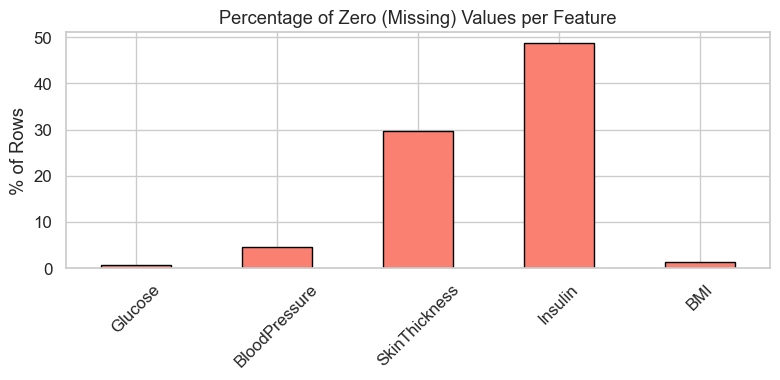

In [6]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = (df[zero_cols] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(1)

zero_summary = pd.DataFrame({'Zero Count': zero_counts, 'Zero %': zero_pct})
print(zero_summary)

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
zero_pct.plot(kind='bar', color='salmon', edgecolor='black', ax=ax)
ax.set_title('Percentage of Zero (Missing) Values per Feature')
ax.set_ylabel('% of Rows')
ax.set_xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Target Distribution (Outcome)

Outcome
0    500
1    268
Name: count, dtype: int64

Class ratio (Negative:Positive) = 500:268 (1.87:1)


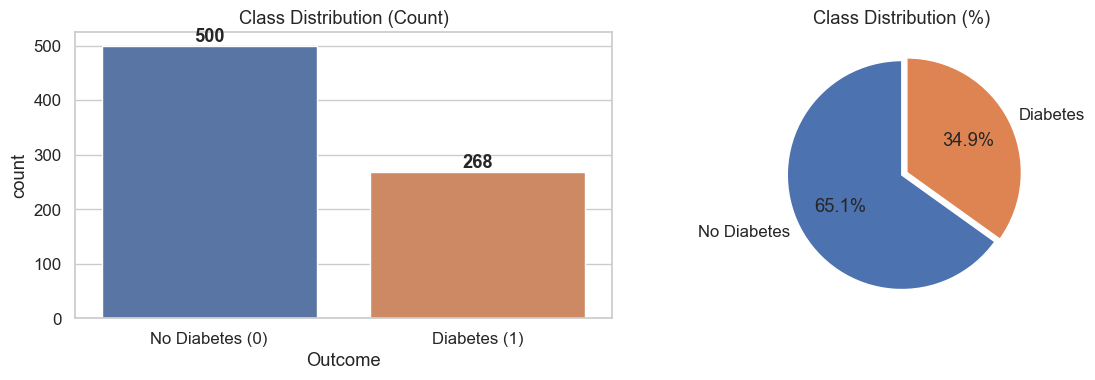

In [8]:
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)
print(f'\nClass ratio (Negative:Positive) = {outcome_counts[0]}:{outcome_counts[1]}'
      f' ({outcome_counts[0]/outcome_counts[1]:.2f}:1)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
# Fix: Changed palette keys from strings '0','1' to integers 0, 1
sns.countplot(x='Outcome', hue='Outcome', data=df, ax=axes[0], legend=False,
              palette={0: '#4c72b0', 1: '#dd8452'})

axes[0].set_title('Class Distribution (Count)')

# Fix: Explicitly set the ticks before setting labels to avoid warnings
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'])

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(outcome_counts, labels=['No Diabetes', 'Diabetes'],
            autopct='%1.1f%%', startangle=90,
            colors=['#4c72b0', '#dd8452'], explode=(0, 0.05))
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

## 6. Feature Distributions (Histograms)

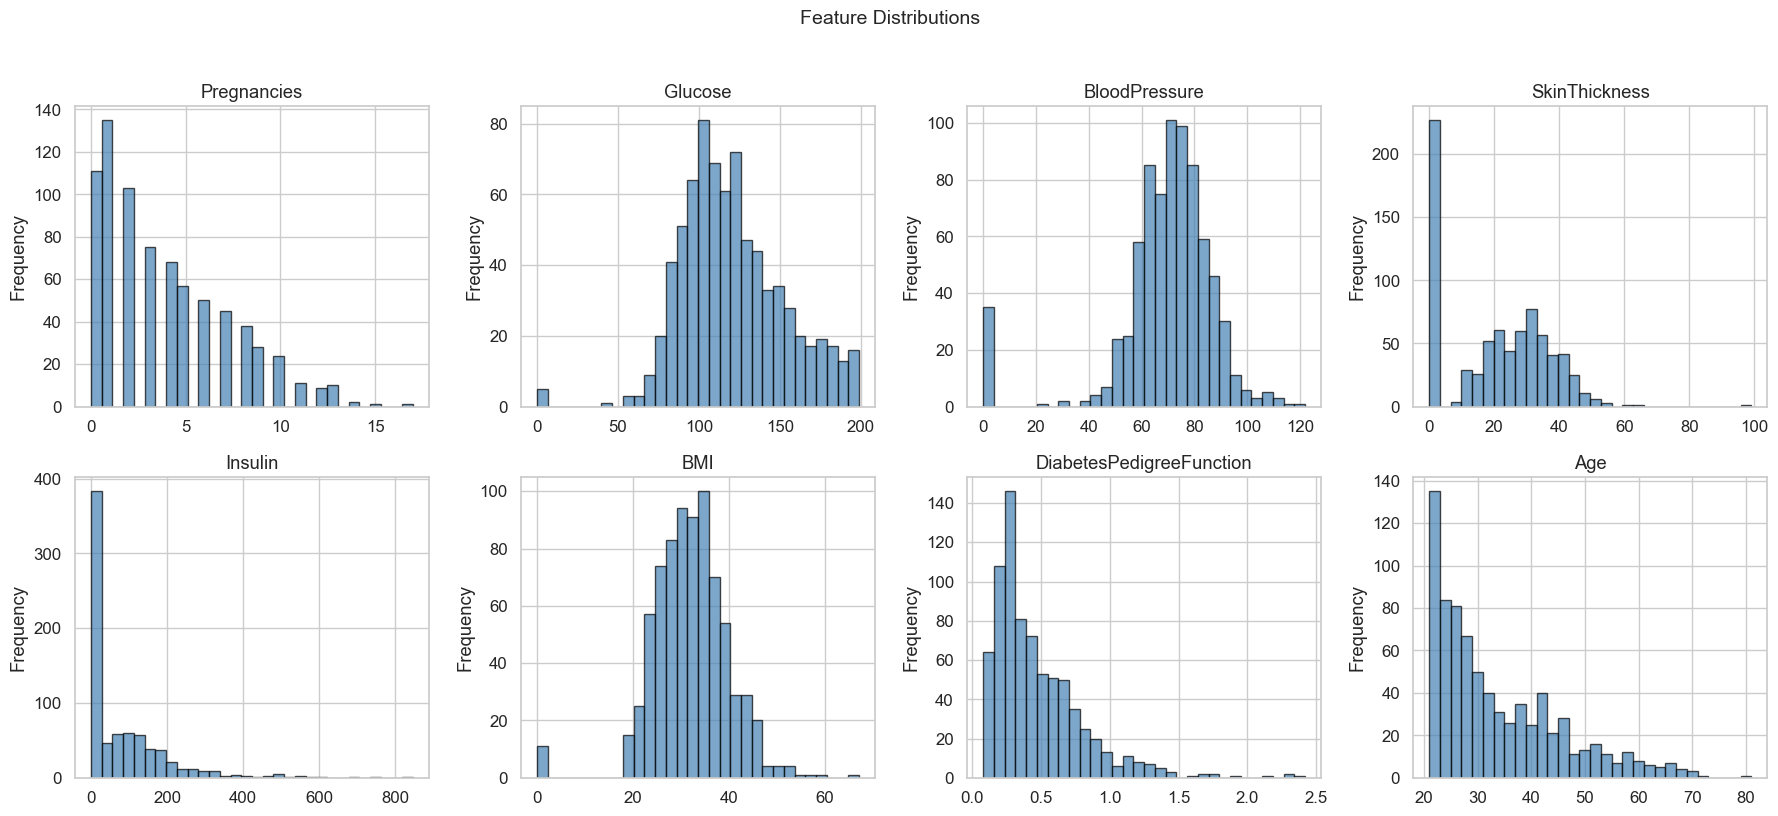

In [9]:
features = df.columns.drop('Outcome')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue',
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Distributions by Outcome (Overlaid Histograms)

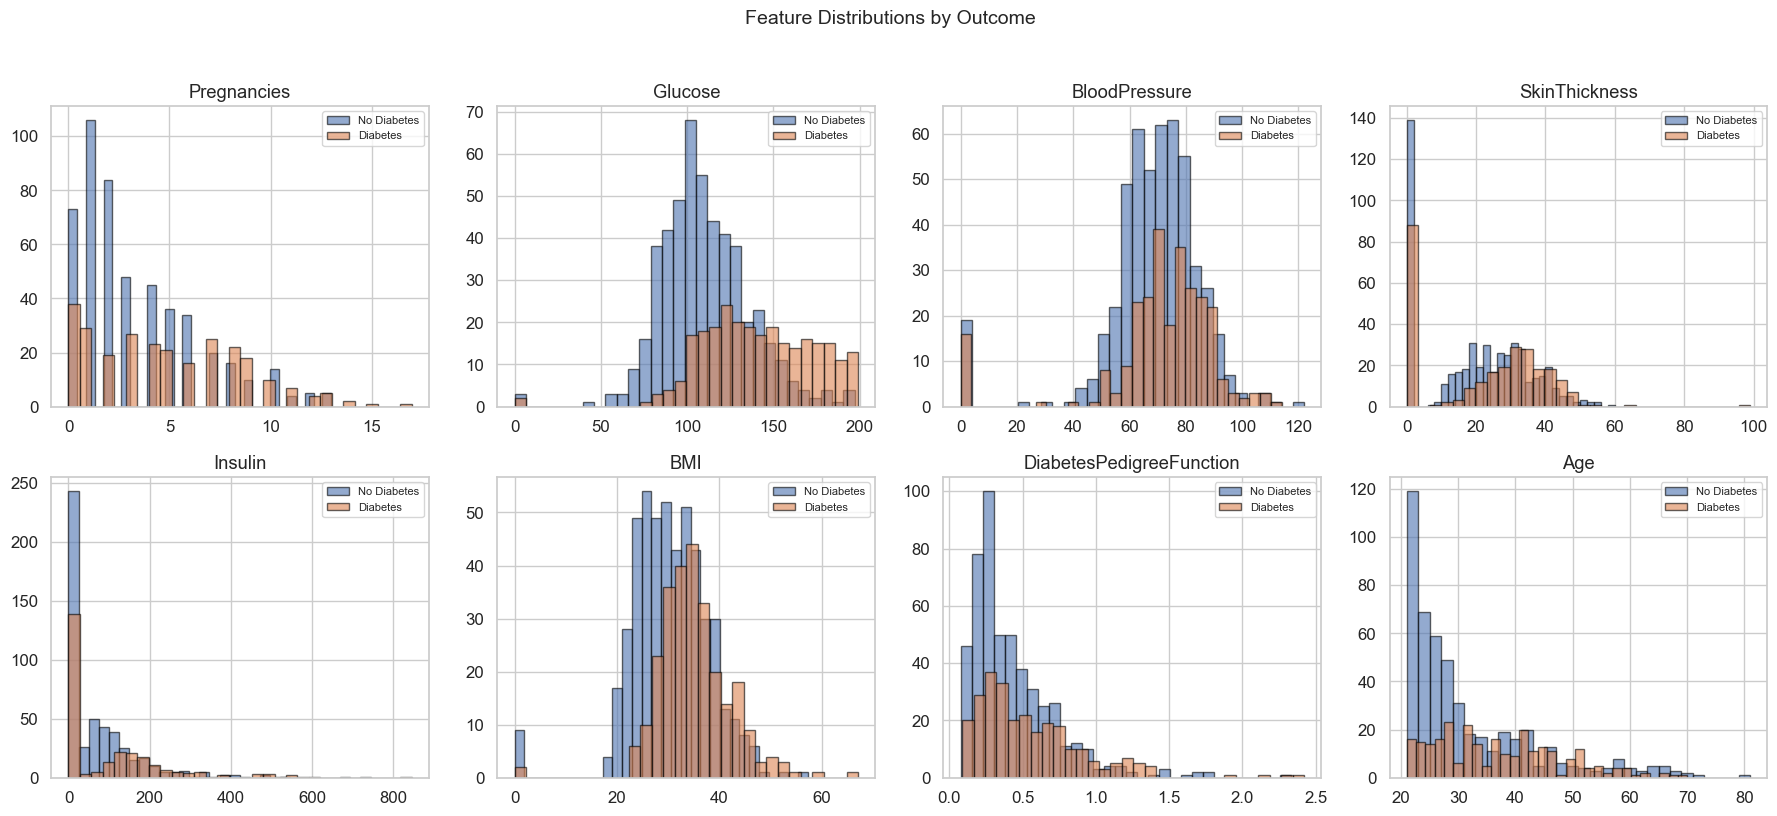

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome'] == 0][col], bins=30, alpha=0.6,
                 label='No Diabetes', color='#4c72b0', edgecolor='black')
    axes[i].hist(df[df['Outcome'] == 1][col], bins=30, alpha=0.6,
                 label='Diabetes', color='#dd8452', edgecolor='black')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Outcome', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap

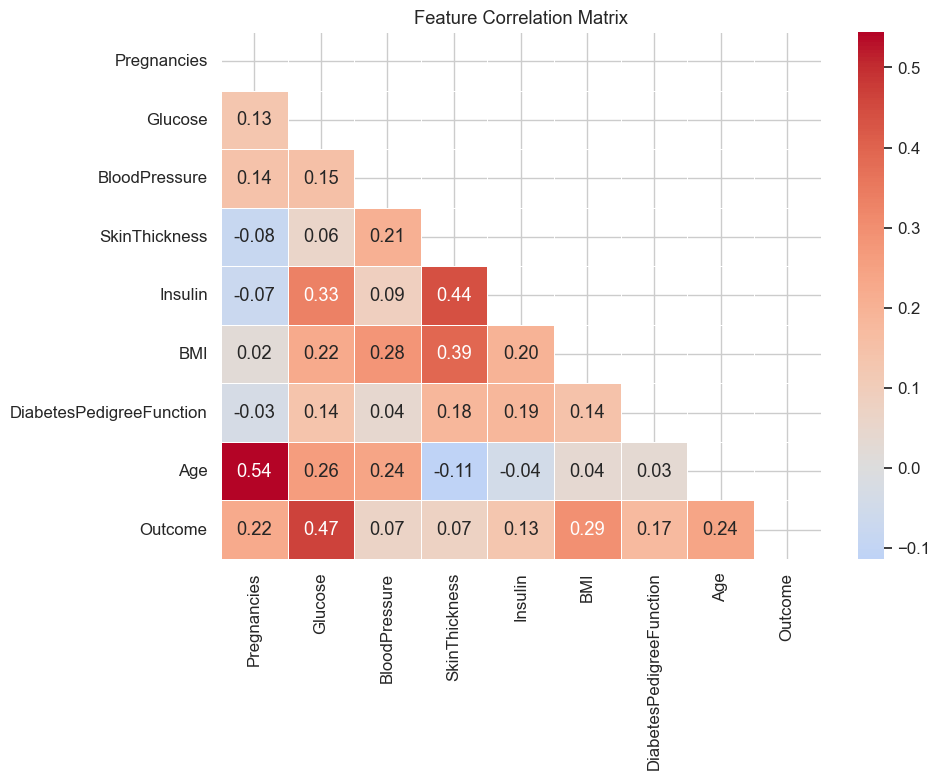

In [11]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Box Plots by Outcome

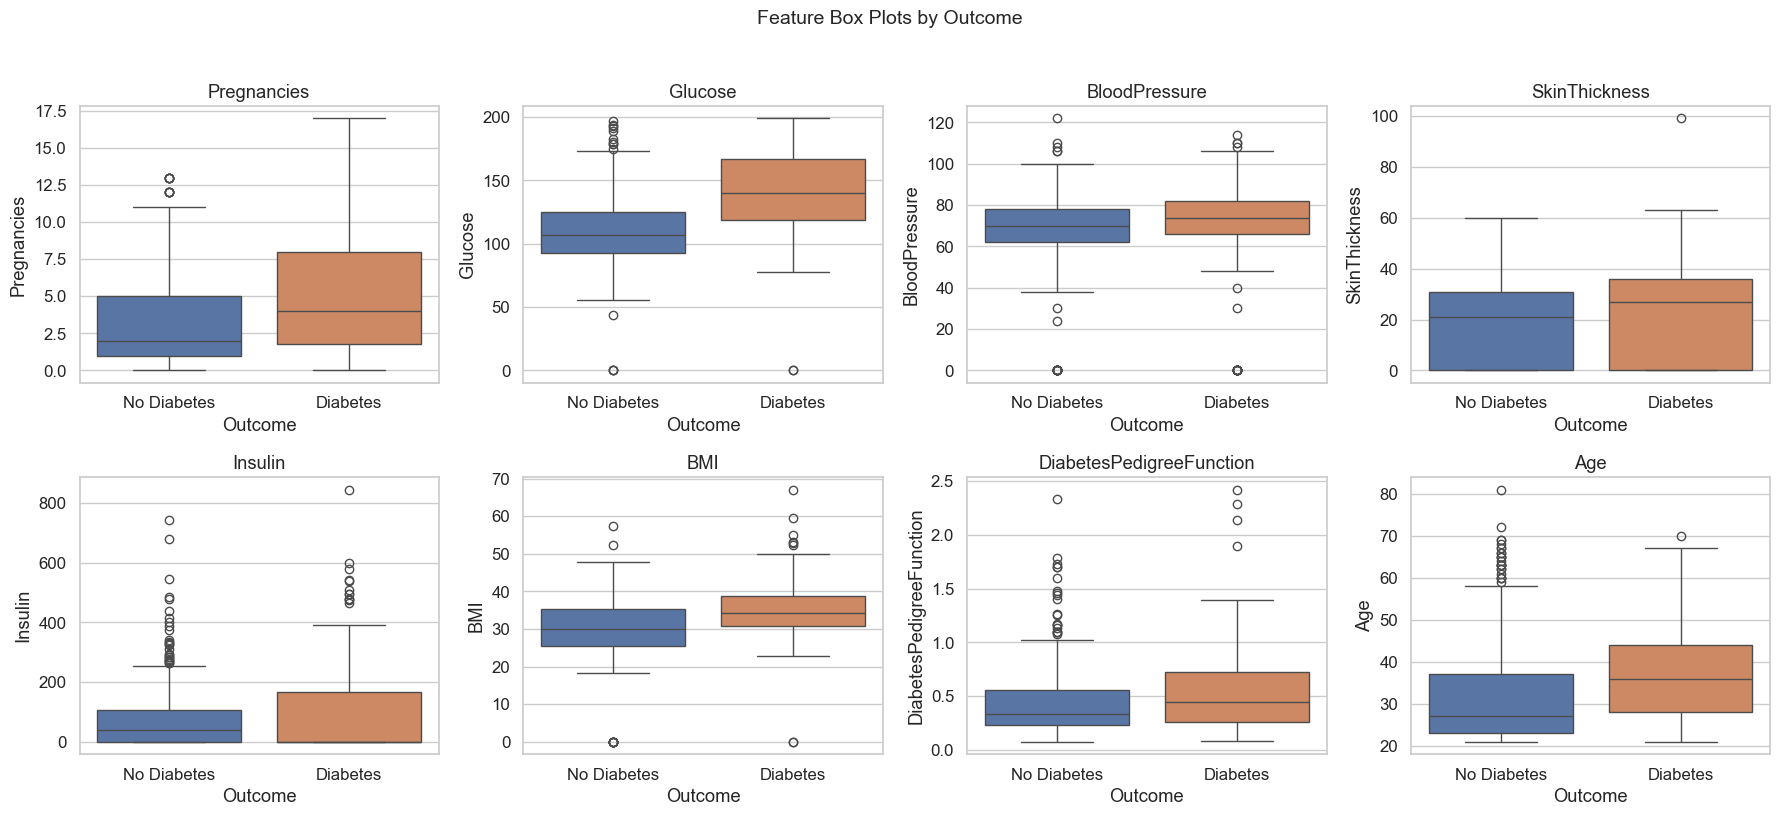

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, hue='Outcome', data=df, ax=axes[i], legend=False,
                palette={0: '#4c72b0', 1: '#dd8452'})
    
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Diabetes', 'Diabetes'])
    axes[i].set_title(col)

plt.suptitle('Feature Box Plots by Outcome', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Pairplot (Key Features)

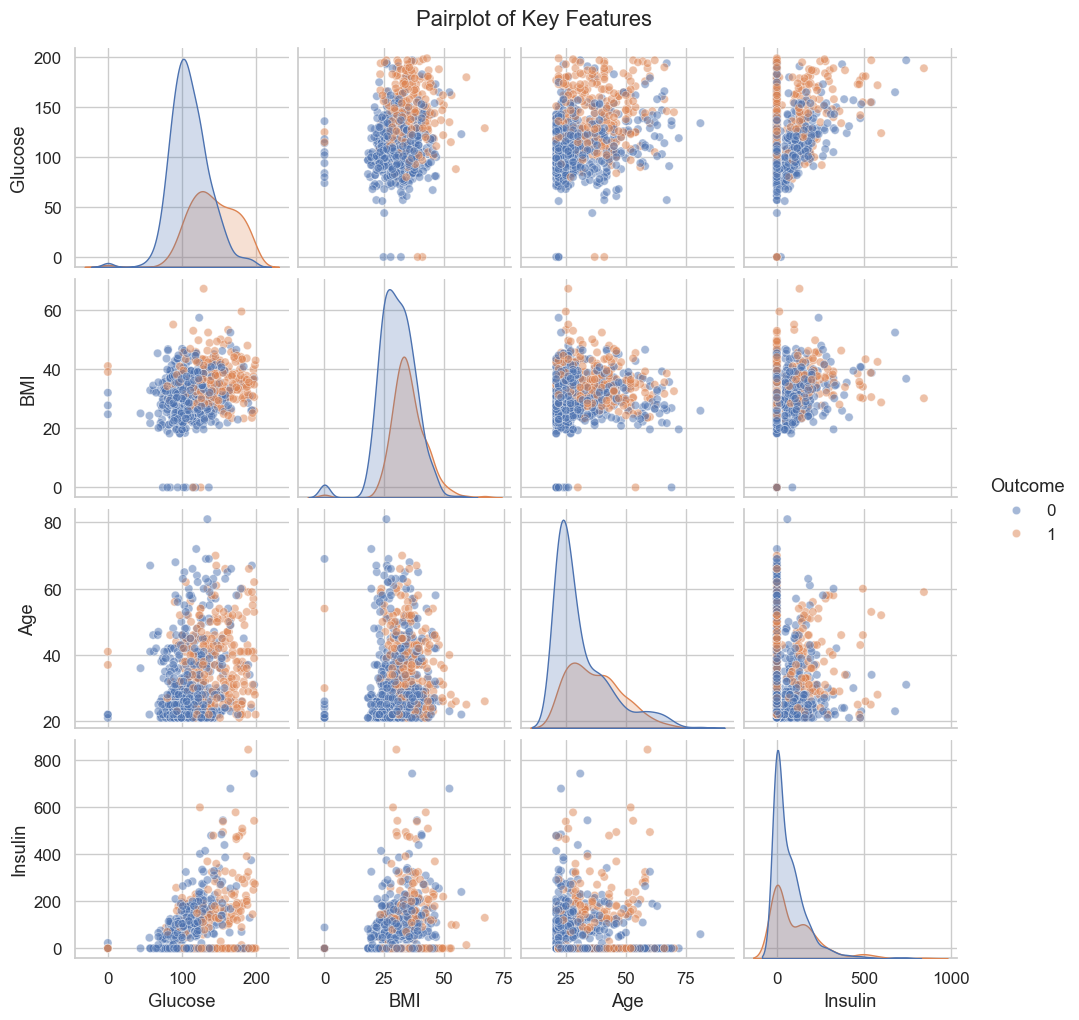

In [16]:
key_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
g = sns.pairplot(df[key_features], hue='Outcome',
                 palette=['#4c72b0', '#dd8452'],
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.figure.suptitle('Pairplot of Key Features', y=1.02)
plt.show()